In [35]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [7]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [9]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [10]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [12]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [13]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [14]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [15]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_age)

In [16]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
118,24.0,247.5208,1,24.00,24.000000,247.5208,247.520800
662,47.0,NaN,0,47.00,47.000000,14.4583,29.785904
224,38.0,90.0000,1,38.00,38.000000,90.0000,90.000000
485,NaN,25.4667,4,28.75,29.785904,25.4667,25.466700
634,9.0,27.9000,5,9.00,9.000000,27.9000,27.900000


In [18]:
#variance is shrinking after adding median and mean
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  204.3495133904614
Age Variance after median imputation:  161.9895663346054
Age Variance after mean imputation:  161.81262452718673
Original Fare variable variance:  2448.197913706318
Fare Variance after median imputation:  2340.0910219753637
Fare Variance after mean imputation:  2324.623996772905


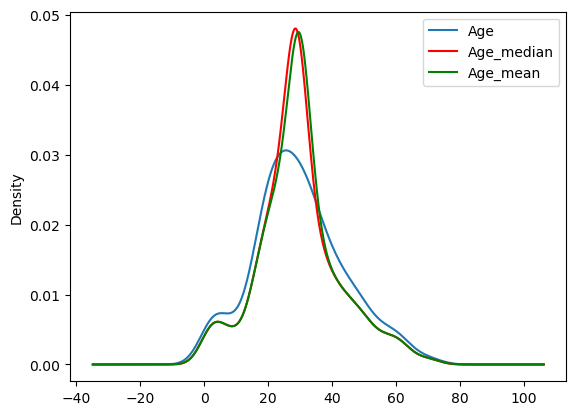

In [22]:
#the age is showing a drastic change in the mean and median value
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

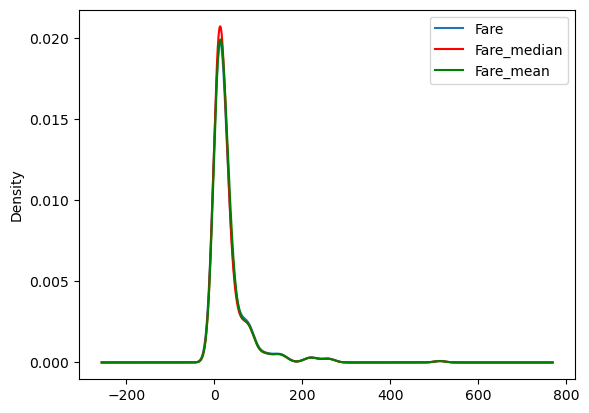

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [23]:
#covariance
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.383530
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.399278
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,54.793876
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.565299
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2326.710504
Fare_mean,66.383530,2448.197914,16.399278,54.793876,52.565299,2326.710504,2324.623997


In [ ]:
#co-relation
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.089754
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205942,0.205660
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.086982,0.089292
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.083461,0.085707
Fare_median,0.087356,1.000000,0.205942,0.086982,0.083461,1.000000,0.997584
Fare_mean,0.089754,1.000000,0.205660,0.089292,0.085707,0.997584,1.000000


<Axes: >

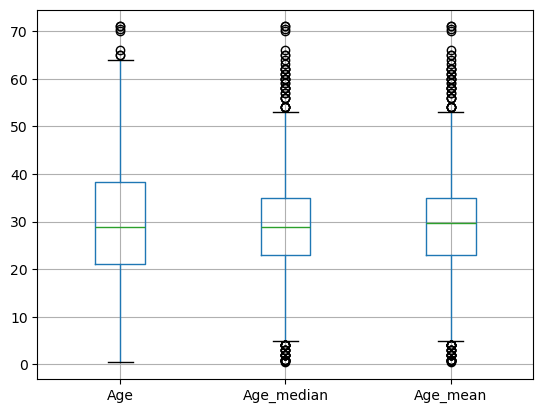

In [27]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot() #the no of outliers are increased

<Axes: >

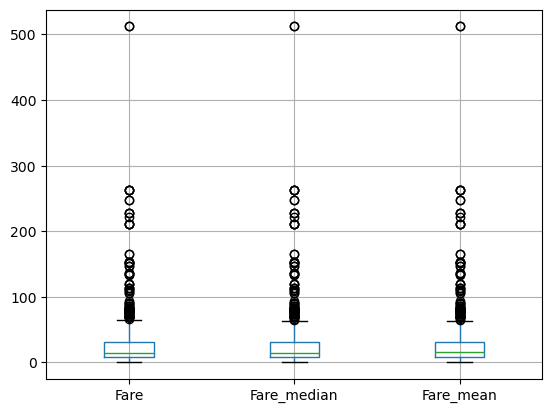

In [29]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot() #no major change as you can see

Using Sklearn

In [30]:
X_train, y_train,X_test, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [39]:
imputer1 = SimpleImputer(strategy='median') #most frequent we use when we have categorical data
imputer2 = SimpleImputer(strategy='mean')

In [38]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [40]:
trf.fit(X_train)

c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [41]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [42]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [47]:
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

# Then apply your transformer
# X_train = trf.transform(X_train)
# X_test = trf.transform(X_test)